<a href="https://colab.research.google.com/github/diptomistry/AlgorithmCPP/blob/main/AI_Search_Algo_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [796]:
import heapq
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
from matplotlib import cm


In [797]:
# ─── Problem Setup ──────────────────────────────────────────────────────────────

# Custom grid:
# 0 = free, 1 = obstacle
grid = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # Row 0
    [0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0],  # Row 1
    [0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0],  # Row 2
    [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0],  # Row 3
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # Row 4
]
grid = np.array(grid)
height, width = grid.shape

start = (3, 0)
goal  = (2, 6)

def manhattan(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

def neighbors(node):
    for dr, dc in [(1,0),(-1,0),(0,1),(0,-1)]:
        nr, nc = node[0] + dr, node[1] + dc
        if 0 <= nr < height and 0 <= nc < width and grid[nr,nc] == 0:
            yield (nr, nc)

In [798]:
# Search templates
def reconstruct(came_from, found):
    path = []
    if found:
        cur = goal
        while cur is not None:
            path.append(cur)
            cur = came_from[cur]
        path.reverse()
    return path

In [799]:
# BFS
def bfs(grid, start, goal):
    from collections import deque
    frontier = deque([start])
    came_from = {start: None}
    expanded=[]
    t0=time.perf_counter()
    found=False
    while frontier:
        node = frontier.popleft()
        expanded.append(node)
        if node==goal:
            found=True
            break
        for nb in neighbors(node):
            if nb not in came_from:
                came_from[nb]=node
                frontier.append(nb)
    t1=time.perf_counter()
    return {'name':'BFS', 'path':reconstruct(came_from, found), 'expanded':expanded,
            'time':t1-t0,'memory':len(came_from),'search_space':len(expanded),
            'complete':found,'optimal':True}

In [800]:
# DFS
def dfs(grid, start, goal):
    frontier=[start]
    came_from={start:None}
    expanded=[]
    t0=time.perf_counter()
    found=False
    while frontier:
        node=frontier.pop()
        if node in expanded:
            continue
        expanded.append(node)
        if node==goal:
            found=True
            break
        for nb in neighbors(node):
            if nb not in came_from:
                came_from[nb]=node
                frontier.append(nb)
    t1=time.perf_counter()
    return {'name':'DFS','path':reconstruct(came_from, found),'expanded':expanded,
            'time':t1-t0,'memory':len(came_from),'search_space':len(expanded),
            'complete':found,'optimal':False}

In [801]:
# Depth-Limited Search
def dls(grid, start, goal, limit):
    expanded=[]
    came_from={start:None}
    t0=time.perf_counter()
    def recursive(node, depth):
        expanded.append(node)
        if node==goal:
            return True
        if depth>=limit:
            return False
        for nb in neighbors(node):
            if nb not in came_from:
                came_from[nb]=node
                if recursive(nb, depth+1):
                    return True
        return False
    found=recursive(start,0)
    t1=time.perf_counter()
    return {'name':f'DLS(limit={limit})','path':reconstruct(came_from,found),'expanded':expanded,
            'time':t1-t0,'memory':len(came_from),'search_space':len(expanded),
            'complete':found,'optimal':False}


In [802]:
# Iterative Deepening Search
def ids(grid, start, goal, max_limit=20):
    for limit in range(max_limit+1):
        res=dls(grid, start, goal, limit)
        if res['complete']:
            res['name']='IDS'
            return res
    return {'name':'IDS','path':[],'expanded':[],'time':0,'memory':0,
            'search_space':0,'complete':False,'optimal':False}

In [803]:
# Uniform Cost Search
def ucs(grid, start, goal):
    frontier=[(0,start)]
    heapq.heapify(frontier)
    came_from={start:None}
    cost_so_far={start:0}
    expanded=[]
    t0=time.perf_counter()
    found=False
    while frontier:
        cost,node=heapq.heappop(frontier)
        expanded.append(node)
        if node==goal:
            found=True
            break
        for nb in neighbors(node):
            new_cost=cost_so_far[node]+1
            if new_cost<cost_so_far.get(nb,float('inf')):
                cost_so_far[nb]=new_cost
                came_from[nb]=node
                heapq.heappush(frontier,(new_cost,nb))
    t1=time.perf_counter()
    return {'name':'UCS','path':reconstruct(came_from,found),'expanded':expanded,
            'time':t1-t0,'memory':len(came_from),'search_space':len(expanded),
            'complete':found,'optimal':True}

In [804]:
# ─── Greedy Best-First Search ──────────────────────────────────────────────────

def best_first(grid, start, goal):
    frontier = [(manhattan(start, goal), start)]
    came_from = {start: None}
    expanded = []
    t0 = time.perf_counter()
    found = False

    while frontier:
        _, node = heapq.heappop(frontier)
        expanded.append(node)
        if node == goal:
            found = True
            break
        for nb in neighbors(node):
            if nb not in came_from:
                came_from[nb] = node
                heapq.heappush(frontier, (manhattan(nb, goal), nb))

    t1 = time.perf_counter()
    # reconstruct path
    path = []
    if found:
        cur = goal
        while cur is not None:
            path.append(cur)
            cur = came_from[cur]
        path.reverse()

    return {
        'name':       'Best-First',
        'path':       path,
        'expanded':   expanded,
        'time':       t1 - t0,
        'memory':     len(came_from),
        'search_space': len(expanded),
        'complete':   found,
        'optimal':    False  # Greedy BF is not guaranteed optimal
    }

In [805]:
# ─── A* Search ─────────────────────────────────────────────────────────────────

def astar(grid, start, goal):
    frontier = [(manhattan(start, goal), 0, start)]
    came_from = {start: None}
    g_score   = {start: 0}
    expanded  = []
    t0 = time.perf_counter()
    found = False

    while frontier:
        _, cost, node = heapq.heappop(frontier)
        expanded.append(node)
        if node == goal:
            found = True
            break
        for nb in neighbors(node):
            tentative_g = g_score[node] + 1
            if tentative_g < g_score.get(nb, float('inf')):
                came_from[nb] = node
                g_score[nb] = tentative_g
                f = tentative_g + manhattan(nb, goal)
                heapq.heappush(frontier, (f, tentative_g, nb))

    t1 = time.perf_counter()
    # reconstruct path
    path = []
    if found:
        cur = goal
        while cur is not None:
            path.append(cur)
            cur = came_from[cur]
        path.reverse()

    return {
        'name':        'A*',
        'path':        path,
        'expanded':    expanded,
        'time':        t1 - t0,
        'memory':      len(came_from),
        'search_space': len(expanded),
        'complete':    found,
        'optimal':     True   # A* with admissible heuristic is optimal
    }

In [806]:
# Weighted A*
def weighted_astar(grid, start, goal, weight=2.0):
    frontier=[(manhattan(start,goal)*weight, 0, start)]
    heapq.heapify(frontier)
    came_from={start:None}
    g_score={start:0}
    expanded=[]
    t0=time.perf_counter()
    found=False
    while frontier:
        _,cost,node=heapq.heappop(frontier)
        expanded.append(node)
        if node==goal:
            found=True
            break
        for nb in neighbors(node):
            tg=g_score[node]+1
            if tg<g_score.get(nb,float('inf')):
                came_from[nb]=node
                g_score[nb]=tg
                f=tg + weight*manhattan(nb,goal)
                heapq.heappush(frontier,(f,tg,nb))
    t1=time.perf_counter()
    return {'name':f'Weighted A*(w={weight})','path':reconstruct(came_from,found),
            'expanded':expanded,'time':t1-t0,'memory':len(came_from),
            'search_space':len(expanded),'complete':found,'optimal':False}

In [807]:
# ─── Run and Compare ────────────────────────────────────────────────────────────

bfs_res = bfs(grid,start,goal)
dfs_res = dfs(grid,start,goal)
dls_res = dls(grid,start,goal,limit=10)
ids_res = ids(grid,start,goal)
ucs_res = ucs(grid,start,goal)
bf_res    = best_first(grid, start, goal)
astar_res = astar    (grid, start, goal)
weighted_astar_res = weighted_astar (grid,start,goal,2.0)



df = pd.DataFrame([{
    'Algorithm':   r['name'],
    'Complete':    r['complete'],
    'Optimal':     r['optimal'],
    'Time (s)':    r['time'],
    'Nodes Stored':r['memory'],
    'Nodes Expanded':r['search_space'],
    'Path Length': len(r['path'])
} for r in (bfs_res,dfs_res,dls_res,ids_res,ucs_res,bf_res,astar_res,weighted_astar_res)])

print(df)

            Algorithm  Complete  Optimal  Time (s)  Nodes Stored  \
0                 BFS      True     True  0.000122            32   
1                 DFS      True    False  0.000121            36   
2       DLS(limit=10)     False    False  0.000075            26   
3                 IDS      True    False  0.000060            26   
4                 UCS      True     True  0.000146            32   
5          Best-First      True    False  0.000106            33   
6                  A*      True     True  0.000147            28   
7  Weighted A*(w=2.0)      True    False  0.000715            29   

   Nodes Expanded  Path Length  
0              30           12  
1              33           28  
2              26            0  
3              26           12  
4              30           12  
5              28           26  
6              26           12  
7              24           12  


In [808]:
def show_initial_grid(grid, start, goal, title="Initial Grid"):
    # build base image
    img = np.full((*grid.shape, 3), 0.85)  # light gray
    for r in range(grid.shape[0]):
        for c in range(grid.shape[1]):
            if grid[r,c] == 1:
                img[r,c] = [0,0,0]  # black obstacles
    # mark start & goal
    img[start] = [0.0, 1.0, 1.0]  # cyan start
    img[goal]  = [0.0,1.0,0.0]  # green goal

    plt.figure(figsize=(6,3))
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')
    # legend
    legend_patches = [
        mpatches.Patch(color=[0.0, 1.0, 1.0], label='Start (Cyan)'),
        mpatches.Patch(color=[0.0,1.0,0.0], label='Goal (Green)'),
        mpatches.Patch(color=[0,0,0],       label='Obstacle (Black)'),
    ]
    plt.legend(handles=legend_patches, loc='lower center',
               bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False)
    plt.show()

In [809]:
def visualize_search(grid, start, goal, result, title):
    img = np.full((*grid.shape, 3), 0.85)  # background (light gray)

    # draw obstacles
    for r in range(grid.shape[0]):
        for c in range(grid.shape[1]):
            if grid[r, c] == 1:
                img[r, c] = [0, 0, 0]  # black

    # heatmap for expanded nodes
    expanded = result['expanded']
    if expanded:
        heatmap = np.zeros(grid.shape)
        for i, (r, c) in enumerate(expanded):
            heatmap[r, c] = i + 1  # index for order

        max_val = heatmap.max()
        if max_val > 0:
            norm_heatmap = heatmap / max_val
            cmap = cm.get_cmap('YlOrRd')  # yellow -> red
            for r in range(grid.shape[0]):
                for c in range(grid.shape[1]):
                    if heatmap[r, c] > 0 and (r, c) != start and (r, c) != goal:
                        img[r, c] = cmap(norm_heatmap[r, c])[:3]  # RGB only

    # start and goal
    img[start] = [0.0, 1.0, 1.0]  # cyan
    img[goal] = [0.0, 1.0, 0.0]   # green

    # plot base image
    plt.figure(figsize=(6, 3))
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')

    # draw arrows for the path
    path = result['path']
    for i in range(len(path) - 1):
        (r1, c1) = path[i]
        (r2, c2) = path[i + 1]

        # skip if start or goal
        if (r1, c1) == start or (r2, c2) == goal:
            continue

        plt.arrow(
            c1, r1,
            c2 - c1, r2 - r1,
            head_width=0.3, head_length=0.3,
            fc='blue', ec='blue', length_includes_head=True
        )

    # legend
    legend_patches = [
        mpatches.Patch(color=[0.0, 1.0, 1.0], label='Start (Cyan)'),
        mpatches.Patch(color=[0.0, 1.0, 0.0], label='Goal (Green)'),
        mpatches.Patch(color=[0, 0, 0],       label='Obstacle (Black)'),
        mpatches.Patch(color='orange',        label='Expanded (Heatmap)'),
        mpatches.Patch(color='blue',          label='Path Arrow'),
    ]
    plt.legend(handles=legend_patches, loc='lower center',
               bbox_to_anchor=(0.5, -0.15), ncol=5, frameon=False)

    plt.show()

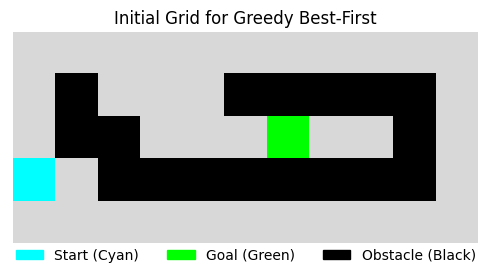

In [810]:
# --- Run and visualize ---
show_initial_grid(grid, start, goal, title="Initial Grid for Greedy Best-First")


<ipython-input-809-d9c23385378e>:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('YlOrRd')  # yellow -> red


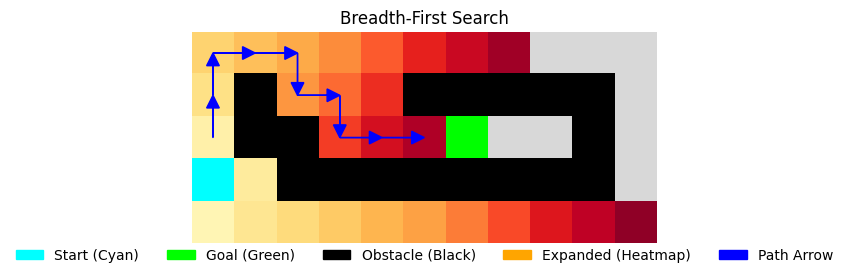

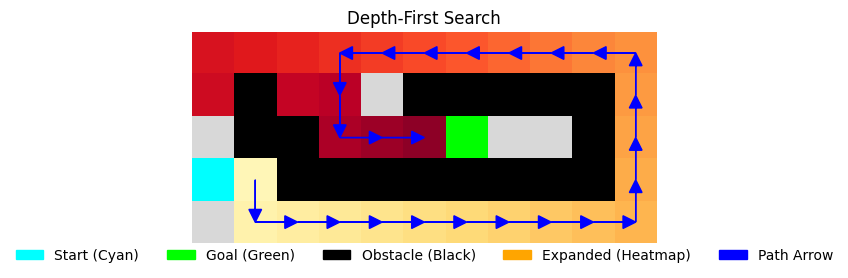

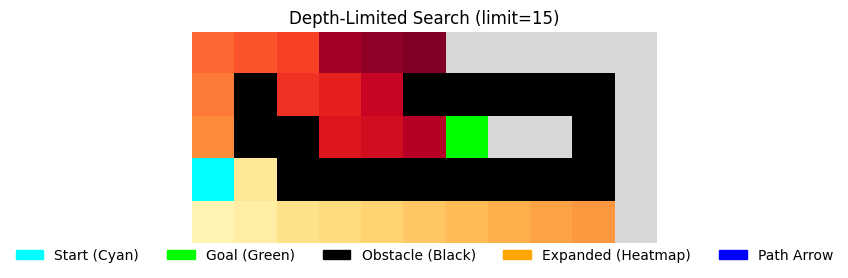

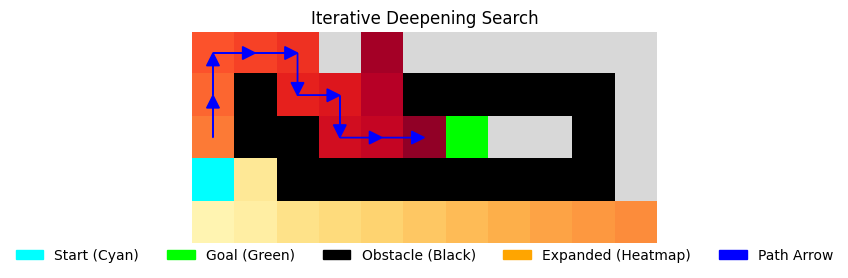

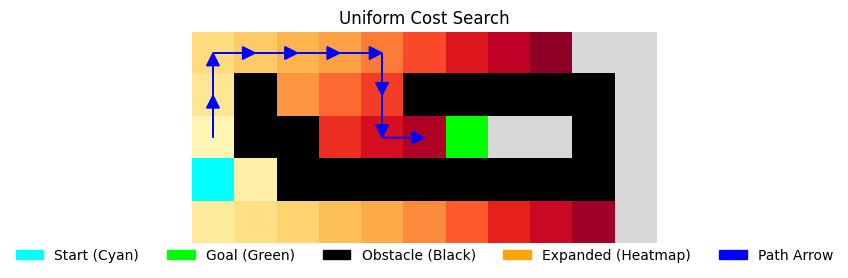

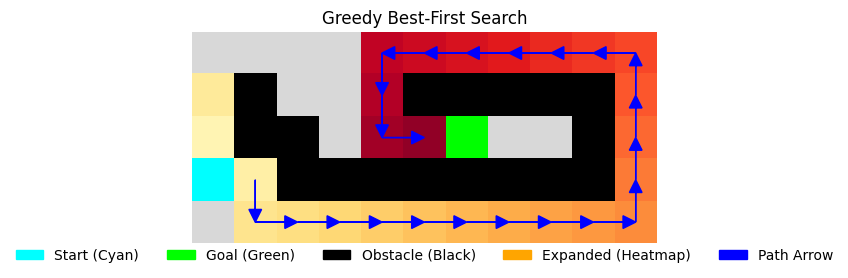

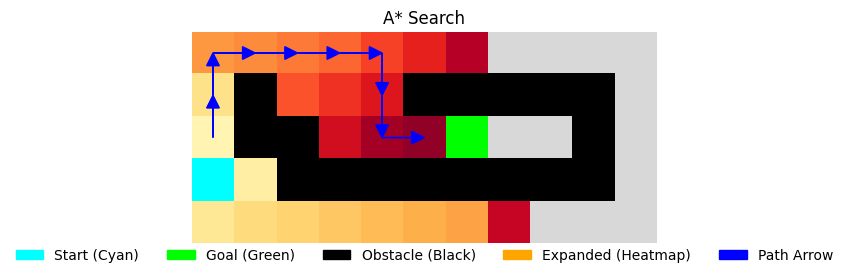

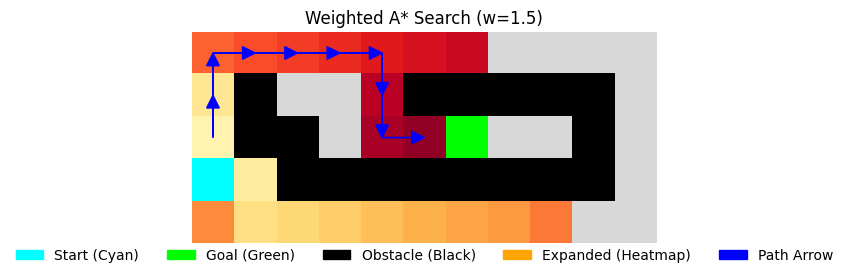

In [811]:
# Visualize each search result
visualize_search(grid, start, goal, bfs_res, 'Breadth-First Search')
visualize_search(grid, start, goal, dfs_res, 'Depth-First Search')
visualize_search(grid, start, goal, dls_res, 'Depth-Limited Search (limit=15)')
visualize_search(grid, start, goal, ids_res, 'Iterative Deepening Search')
visualize_search(grid, start, goal, ucs_res, 'Uniform Cost Search')
visualize_search(grid, start, goal, bf_res, 'Greedy Best-First Search')
visualize_search(grid, start, goal, astar_res, 'A* Search')
visualize_search(grid, start, goal, weighted_astar_res, 'Weighted A* Search (w=1.5)')

